**Thêm thư viện**

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


**Load dữ liệu**

In [4]:
OUT_DIR = "outputs/pytorch_mlp"
os.makedirs(OUT_DIR, exist_ok=True)

X_train = pd.read_csv(f"X_train_scaled.csv").values
X_val = pd.read_csv(f"X_val_scaled.csv").values
X_test = pd.read_csv(f"X_test_scaled.csv").values

y_train = pd.read_csv(f"y_train.csv")["energy_per_atom"].values.reshape(-1, 1)
y_val = pd.read_csv(f"y_val.csv")["energy_per_atom"].values.reshape(-1, 1)
y_test = pd.read_csv(f"y_test.csv")["energy_per_atom"].values.reshape(-1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64,
    shuffle=True
)


In [6]:
class EnergyMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = EnergyMLP(input_dim=X_train.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

n_epochs = 500
patience = 50
best_val_loss = float("inf")
best_state = None
wait = 0

history = []

for epoch in range(n_epochs):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = criterion(val_pred, y_val_tensor).item()

    train_loss = float(np.mean(train_losses))

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

    if wait >= patience:
        print("Early stopping at epoch:", epoch)
        break

model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    pred = model(X_test_tensor).cpu().numpy().reshape(-1)

y_test_flat = y_test.reshape(-1)

mae = mean_absolute_error(y_test_flat, pred)
rmse = np.sqrt(mean_squared_error(y_test_flat, pred))
r2 = r2_score(y_test_flat, pred)

results = pd.DataFrame([{
    "model": "PyTorch_MLP",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
}])

display(results)

results.to_csv(f"{OUT_DIR}/pytorch_mlp_results.csv", index=False)


Epoch 0: train_loss=18287.782990, val_loss=8786.917969
Epoch 20: train_loss=73.436675, val_loss=9.231911
Epoch 40: train_loss=61.648267, val_loss=7.338459
Epoch 60: train_loss=58.493287, val_loss=4.078792
Epoch 80: train_loss=52.218802, val_loss=5.493185
Epoch 100: train_loss=47.859693, val_loss=13.956743
Epoch 120: train_loss=43.046042, val_loss=3.254050
Epoch 140: train_loss=35.808036, val_loss=1.695980
Epoch 160: train_loss=30.691654, val_loss=4.365258
Epoch 180: train_loss=23.987489, val_loss=2.978499
Epoch 200: train_loss=17.117486, val_loss=0.548835
Epoch 220: train_loss=7.869027, val_loss=0.299973
Epoch 240: train_loss=2.507653, val_loss=0.062441
Epoch 260: train_loss=0.277377, val_loss=0.142391
Epoch 280: train_loss=0.022159, val_loss=0.019637
Epoch 300: train_loss=0.027553, val_loss=0.040823
Epoch 320: train_loss=0.023291, val_loss=0.124966
Epoch 340: train_loss=0.015999, val_loss=0.017833
Epoch 360: train_loss=0.013265, val_loss=0.005807
Epoch 380: train_loss=0.008188, val_lo

,model,MAE,RMSE,R2
0,PyTorch_MLP,0.023387,0.031816,0.945599


In [7]:
pred_df = pd.DataFrame({
    "actual_energy_per_atom": y_test_flat,
    "predicted_energy_per_atom": pred,
    "error": pred - y_test_flat,
    "absolute_error": np.abs(pred - y_test_flat),
})

pred_df.to_csv(f"{OUT_DIR}/pytorch_mlp_predictions.csv", index=False)

history_df = pd.DataFrame(history)
history_df.to_csv(f"{OUT_DIR}/pytorch_mlp_training_history.csv", index=False)


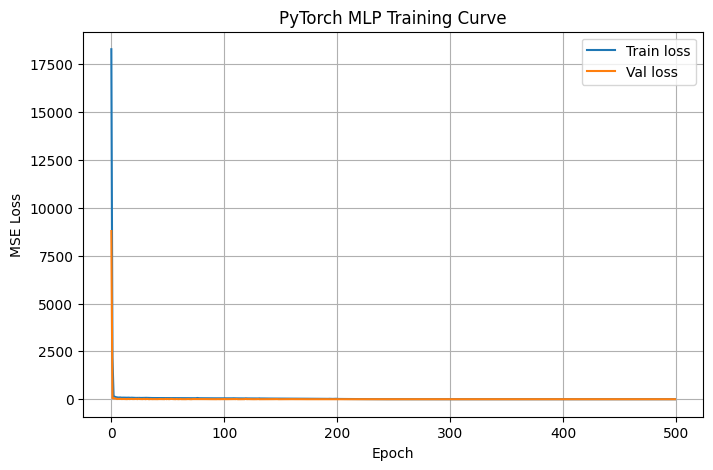

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PyTorch MLP Training Curve")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/pytorch_mlp_training_curve.png", dpi=200, bbox_inches="tight")
plt.show()

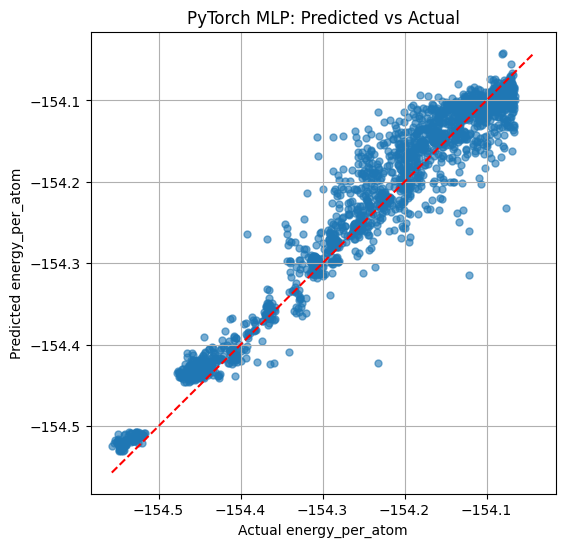

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_flat, pred, alpha=0.6, s=25)
min_v = min(y_test_flat.min(), pred.min())
max_v = max(y_test_flat.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "r--")
plt.xlabel("Actual energy_per_atom")
plt.ylabel("Predicted energy_per_atom")
plt.title("PyTorch MLP: Predicted vs Actual")
plt.grid(True)
plt.savefig(f"{OUT_DIR}/pytorch_mlp_predicted_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

torch.save(model.state_dict(), f"{OUT_DIR}/pytorch_mlp_model.pt")


In [10]:
!zip -r pytorch_mlp_results.zip outputs/pytorch_mlp

  adding: outputs/pytorch_mlp/ (stored 0%)
  adding: outputs/pytorch_mlp/pytorch_mlp_model.pt (deflated 9%)
  adding: outputs/pytorch_mlp/pytorch_mlp_predicted_vs_actual.png (deflated 5%)
  adding: outputs/pytorch_mlp/pytorch_mlp_results.csv (deflated 7%)
  adding: outputs/pytorch_mlp/pytorch_mlp_predictions.csv (deflated 70%)
  adding: outputs/pytorch_mlp/pytorch_mlp_training_curve.png (deflated 19%)
  adding: outputs/pytorch_mlp/pytorch_mlp_training_history.csv (deflated 50%)
